## Import

In [1]:
import torch
import seaborn as sns
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

import matplotlib.colors as mcolors

from sde_routines_scalar_new import solve_sde, plot_SD_results
from utils import BimodalGaussianMixture, l1l2_sampler, generate_signed_exponential, kl_divergence, entropy, histedges_equalN, gen_unbalanced, bimodal

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

c1='blue'
c2='red'

def colorFader(c1,c2,mix=0):
    c1=np.array(mpl.colors.to_rgb(c1))
    c2=np.array(mpl.colors.to_rgb(c2))
    return mpl.colors.to_hex((1-mix)*c1 + mix*c2)

# Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Data generation

In [101]:
n1 = int(1e6)
n_steps = int(1e6)

beta = .5

x1 = torch.from_numpy(bimodal(n1,beta)).cuda()

#x1 = gen_unbalanced(n1, n_steps, beta, device='cuda')
#x1 = torch.load('data/1e6_beta_15.pt').cuda()

Constante de normalisation Z ≈ 42.1725


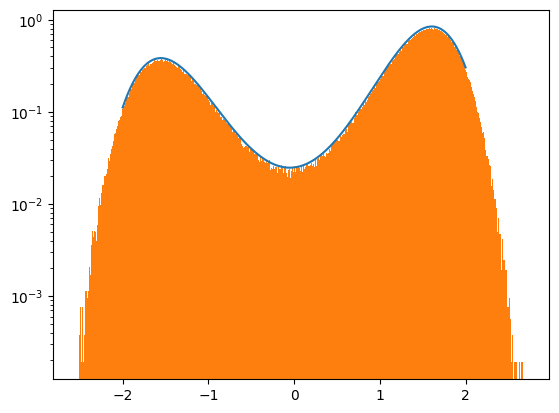

In [102]:
def U(x, beta):
    return -(-beta * x**4 + 5 * beta * x**2 +  0.5*beta * x)#beta*(.5*x**2-np.abs(x)+x/8)

beta = .5

x_space = np.linspace(-2,2,1000)

plt.plot(x_space, 250*np.exp(-U(x_space, beta))/np.exp(-U(x_space, beta)).sum())
plt.hist(x1.cpu(), density=True, bins='sqrt')

plt.yscale('log')

plt.show()

## Sampling

In [60]:
xt_to_save = {}

In [61]:
potential_names = ['x', 'x2', 'x3', 'x4']

nt = 10000
t = torch.linspace(0, 1, nt + 1)

sigma = 5 # 1000 pour 3

In [69]:
n1 = int(1e7)

beta = .5

x1 = torch.from_numpy(bimodal(n1,beta)).cuda()#torch.randn(n1).cuda()*.5#torch.from_numpy(bimodal(n1,beta)).cuda()

Constante de normalisation Z ≈ 42.1725


In [70]:
x0, xt, barphi_e, barphi_p, eta_t, eta_t2, dH_t_bound = solve_sde(x1, n1, t, [sigma for i in range(nt+1)],
                                                                  potential_names=potential_names, device=device, std_init=1) #'x', 'x_abs', 'x2'

Step 0/10000
Step 200/10000
Step 400/10000
Step 600/10000
Step 800/10000
Step 1000/10000
Step 1200/10000
Step 1400/10000
Step 1600/10000
Step 1800/10000
Step 2000/10000
Step 2200/10000
Step 2400/10000
Step 2600/10000
Step 2800/10000
Step 3000/10000
Step 3200/10000
Step 3400/10000
Step 3600/10000
Step 3800/10000
Step 4000/10000
Step 4200/10000
Step 4400/10000
Step 4600/10000
Step 4800/10000
Step 5000/10000
Step 5200/10000
Step 5400/10000
Step 5600/10000
Step 5800/10000
Step 6000/10000
Step 6200/10000
Step 6400/10000
Step 6600/10000
Step 6800/10000
Step 7000/10000
Step 7200/10000
Step 7400/10000
Step 7600/10000
Step 7800/10000
Step 8000/10000
Step 8200/10000
Step 8400/10000
Step 8600/10000
Step 8800/10000
Step 9000/10000
Step 9200/10000
Step 9400/10000
Step 9600/10000
Step 9800/10000


SDE interpolation complete!


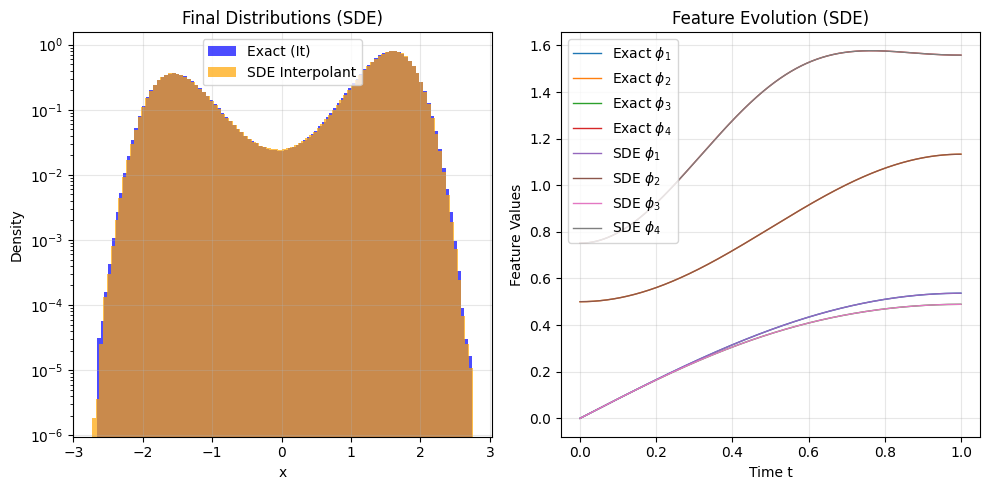


Final Results:
Final feature error: 0.000011
Max feature error during interpolation: 0.000011

Distribution Statistics:
Target (x1) - Mean: 0.5367, Std: 1.4065
Initial (x0) - Mean: -0.0001, Std: 1.0002
Final SDE interpolant - Mean: 0.5367, Std: 1.4065


In [71]:
_ = plot_SD_results(x0, x1, xt, barphi_e, barphi_p, t, sigma, nt, potential_names)

### Analysis of $\theta$

Monomial potentials are defined as $x^k/k$, so the computed $\theta$ need to be renormalized.

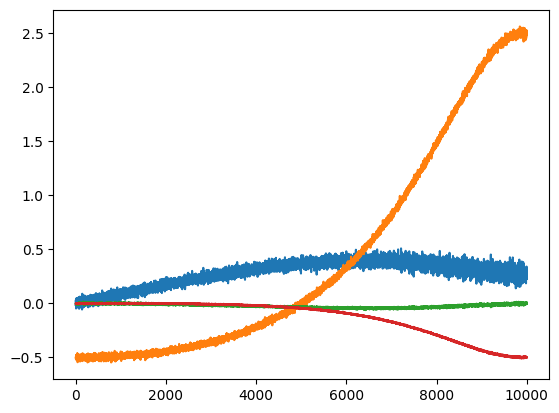

In [83]:
plt.plot(eta_t2/torch.Tensor([1,2,3,4]))
plt.show()

In [99]:
print('Target theta:', str(torch.Tensor([beta/2, 5*beta, 0, -beta])))
print('Estimated theta at t=1:', str(eta_t2[-1]/torch.Tensor([1,2,3,4])))
print('Estimated theta averaged on the 10 last steps:', str(eta_t2[-10:].mean(0)/torch.Tensor([1,2,3,4])))

Target theta: tensor([ 0.2500,  2.5000,  0.0000, -0.5000])
Estimated theta at t=1: tensor([ 0.2279,  2.5234,  0.0095, -0.5032])
Estimated theta averaged on the 10 last steps: tensor([ 2.7524e-01,  2.5032e+00, -1.5606e-03, -4.9993e-01])
